# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())
# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001], 
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
results = pd.DataFrame(svm_grid_search.cv_results_)[[
    'params', 
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score', 
]]
results = results.sort_values('rank_test_score')
print(results.head(10))

                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
5         0.015266                2  
3         0.015266               

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500), 
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(base_models['RandomForest'], rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)
print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500), 
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(base_models['RandomForest'], rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)
print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [12]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
best_svm = svm_grid_search.best_estimator_
best_rf = rf_random_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
print('SVM')
print(classification_report(y_test, y_pred_svm))
print('\nRandomForest')
print(classification_report(y_test, y_pred_rf))
print()
baseline_test_results = {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    baseline_test_results[name] = f1_macro
    print(f"{name:25s} F1-macro = {f1_macro:.4f}")
for name, score in baseline_test_results.items():
    print(f"{name:<25s} {score:.4f}")
print(f"{'SVM (оптимизированный)':<25s} {f1_score(y_test, y_pred_svm, average='macro'):.4f} {'✅ улучшение' if f1_score(y_test, y_pred_svm, average='macro') > baseline_test_results['SVM'] else '⚠️ без изменений'}")

print(f"{'RandomForest (оптимизир.)':<25s} {f1_score(y_test, y_pred_rf, average='macro'):.4f} {'✅ улучшение' if f1_score(y_test, y_pred_rf, average='macro') > baseline_test_results['RandomForest'] else '⚠️ без изменений'}")

print(f"Улучшение SVM: {(f1_score(y_test, y_pred_svm, average='macro') - baseline_test_results['SVM']) * 100:+.2f}%")
print(f"Улучшение RandomForest: {(f1_score(y_test, y_pred_rf, average='macro') - baseline_test_results['RandomForest']) * 100:+.2f}%")
print("Лучшие параметры SVM:", svm_grid_search.best_params_)
print("Лучшие параметры RandomForest:", rf_random_search.best_params_)

print(f"SVM - Разница между CV ({svm_grid_search.best_score_:.4f}) и тестом ({f1_score(y_test, y_pred_svm, average='macro'):.4f}): {(f1_score(y_test, y_pred_svm, average='macro') - svm_grid_search.best_score_)*100:+.2f}%")
print(f"RF - Разница между CV ({rf_random_search.best_score_:.4f}) и тестом ({f1_score(y_test, y_pred_rf, average='macro'):.4f}): {(f1_score(y_test, y_pred_rf, average='macro') - rf_random_search.best_score_)*100:+.2f}%")
for name, (mean, std) in baseline_results.items():
    print(f"{name}: mean = {mean:.4f}, std = {std:.4f}")

svm_best_idx = svm_grid_search.best_index_
svm_cv_std = svm_grid_search.cv_results_['std_test_score'][svm_best_idx]
print(f"SVM Grid Search: mean = {svm_grid_search.best_score_:.4f}, std = {svm_cv_std:.4f}")

rf_best_idx = rf_random_search.best_index_
rf_cv_std = rf_random_search.cv_results_['std_test_score'][rf_best_idx]
print(f"RF Random Search: mean = {rf_random_search.best_score_:.4f}, std = {rf_cv_std:.4f}")
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

SVM
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RandomForest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM                       F1-macro = 0.9812
RandomForest              F1-macro = 0.9526
LogisticRegression        F1-macro = 0.9812
SVM                       0.9812
RandomForest              0.9526
LogisticRegression        0.9812
SVM (оптимизированный)    0.9812 ⚠️ без изменений
RandomForest (оптимизир.) 0.9526 ⚠️ без измене

| Модель                | CV F1 (mean±std) | Test F1       |
|-----------------------|------------------|---------------|
| SVM baseline          |0,9812 ± 0,0193   |    0,9812     |
| SVM Grid Search       |0,9786 ± 0,0176   |    0,9812     |
| RF baseline           |0,9504 ± 0,0255   |    0,9526     |
| RF Random Search      |0,9554 ± 0,0204   |    0,9526     |

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

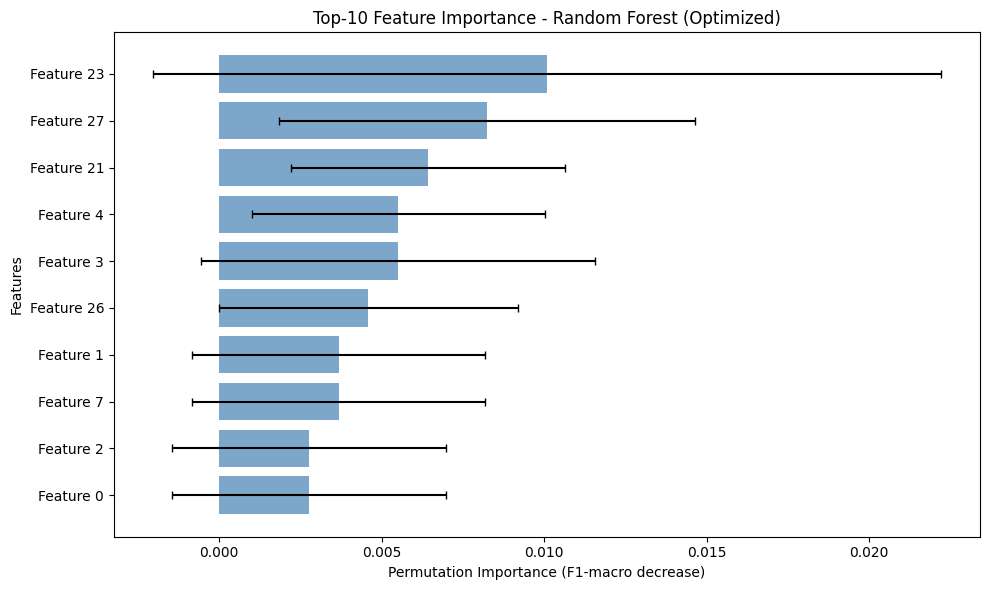

In [13]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro')

feature_importance = pi_result.importances_mean
feature_importance_std = pi_result.importances_std
sorted_idx = np.argsort(feature_importance)[::-1]  
top_n = 10
# Построим bar plot топ-10 признаков
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feature_importance[sorted_idx[:top_n]][::-1], 
         xerr=feature_importance_std[sorted_idx[:top_n]][::-1], 
         capsize=3, alpha=0.7, color='steelblue')
plt.yticks(range(top_n), [f"Feature {i}" for i in sorted_idx[:top_n]][::-1])
plt.xlabel('Permutation Importance (F1-macro decrease)')
plt.ylabel('Features')
plt.title('Top-10 Feature Importance - Random Forest (Optimized)')
plt.tight_layout()
plt.show()

In [14]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_builtin_importance = best_rf.feature_importances_
sorted_idx_builtin = np.argsort(rf_builtin_importance)[::-1]
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns
    print("\nТоп-5 по Permutation Importance:")
    for i in range(5):
        idx = sorted_idx[i]
        print(f"{i+1}. {feature_names[idx]:<25} Importance: {feature_importance[idx]:.4f} ± {feature_importance_std[idx]:.4f}")
    print("\nТоп-5 по встроенной feature_importances_ (Gini importance):")
    for i in range(5):
        idx = sorted_idx_builtin[i]
        print(f"{i+1}. {feature_names[idx]:<25} Importance: {rf_builtin_importance[idx]:.4f}")
    top5_perm = set(sorted_idx[:5])
    top5_builtin = set(sorted_idx_builtin[:5])
    print(f"Топ-5 Permutation Importance признаки: {[feature_names[i] for i in sorted_idx[:5]]}")
    print(f"Топ-5 Built-in Importance признаки: {[feature_names[i] for i in sorted_idx_builtin[:5]]}")
    print(f"\nСовпадающие признаки: {len(top5_perm & top5_builtin)} из 5")
    print(f"Общие признаки: {[feature_names[i] for i in (top5_perm & top5_builtin)]}")
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?


Топ-5 по Permutation Importance:
1. worst area                Importance: 0.0101 ± 0.0121
2. worst concave points      Importance: 0.0083 ± 0.0064
3. worst texture             Importance: 0.0064 ± 0.0042
4. mean smoothness           Importance: 0.0055 ± 0.0045
5. mean area                 Importance: 0.0055 ± 0.0061

Топ-5 по встроенной feature_importances_ (Gini importance):
1. worst area                Importance: 0.1271
2. worst perimeter           Importance: 0.1142
3. worst concave points      Importance: 0.1093
4. worst radius              Importance: 0.0825
5. mean concave points       Importance: 0.0722
Топ-5 Permutation Importance признаки: ['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']
Топ-5 Built-in Importance признаки: ['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']

Совпадающие признаки: 2 из 5
Общие признаки: ['worst concave points', 'worst area']


Как видим, порядок не совпадает, вполне возможно из-за корелляции признаков, вычислительной сложности, разных метрик оценки, ну и зависимости 
от масштаба значений. Некоторые признаки имеют высокий PI, но низкую встроенную важность, или наоборот. Что это может означать? Высокой PI, как я понял, это
встроенная важность (Сложные взаимодействия признаков и имеется важность для специфических подгрупп) и низкий PI - высокая надежность (имеется избыточность и
корреляция, разные масштабы).

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

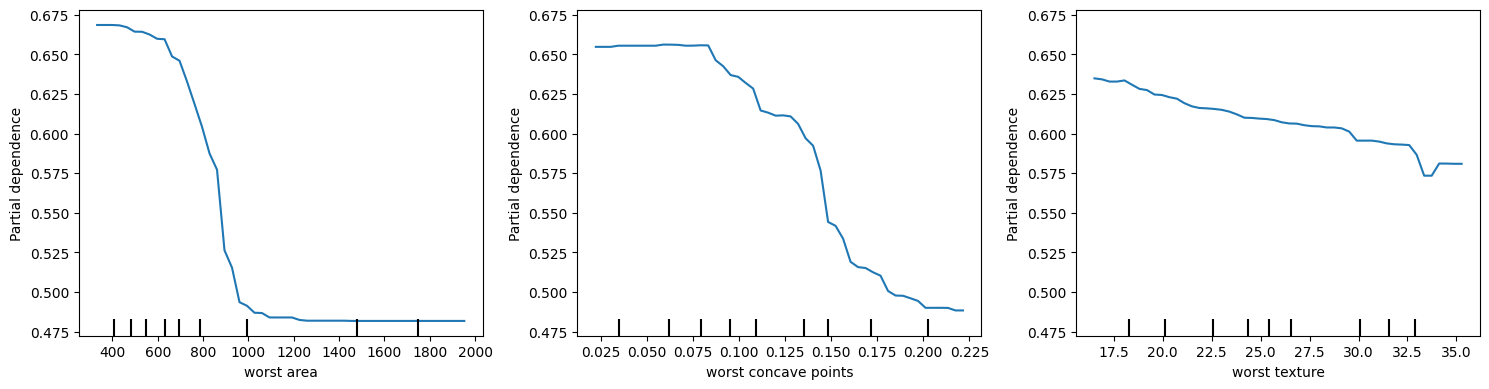

In [15]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
sorted_idx_pi = np.argsort(pi_result.importances_mean)[::-1]
top3_idx = sorted_idx_pi[:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=top3_idx, 
    kind='average',  
    ax=ax,
    n_jobs=-1,
    grid_resolution=50 
)
plt.tight_layout()
plt.show()

Самый важный признак:
Признак: worst area
Важность: 0.0101 ± 0.0121


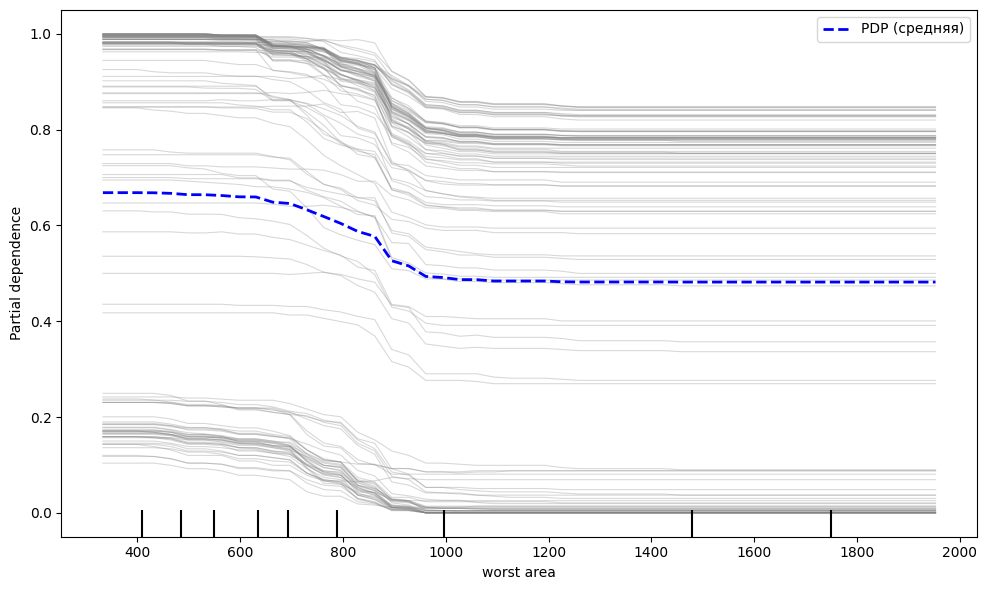

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_idx = sorted_idx_pi[0]
print("Самый важный признак:")
if hasattr(X_test, 'columns'):
    most_important_name = X_test.columns[most_important_idx]
    print(f"Признак: {most_important_name}")
    print(f"Важность: {pi_result.importances_mean[most_important_idx]:.4f} ± {pi_result.importances_std[most_important_idx]:.4f}")
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[most_important_idx],
    kind='both',  # PDP + все ICE линии
    ax=ax,
    n_jobs=-1,
    grid_resolution=50,
    line_kw={'linewidth': 2, 'color': 'blue', 'label': 'PDP (средняя)'},
    ice_lines_kw={'alpha': 0.3, 'linewidth': 0.8, 'color': 'gray'},
    random_state=42
)
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [17]:
pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 2.6 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 3.6 MB/s eta 0:00:11
   - -------------------------------------- 1.3/39.2 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.8/39.2 MB 3.4 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/39.2 MB 3.4 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/39.2 MB 3.3 MB/s eta 0:00:11
   ---- ----------------------------------- 3.9/39.2 MB 3.3 MB/s eta 0:00:11
   ---- ----------------------------------- 4.7/39.2 MB 3.3 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/39.2 MB 3.3 MB/s eta 0:00:11
   ------ --------------------------------- 6.0/39.2 MB 3.3 MB/s eta 0:00:11
   ------ --------------------------------- 6.6/39.2 MB 3.2 MB/s eta 0:00:11
   ------ --


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print("Форма SHAP значений:")
print(f"  shap_values: {shap_values.shape}")

Форма SHAP значений:
  shap_values: (114, 30, 2)


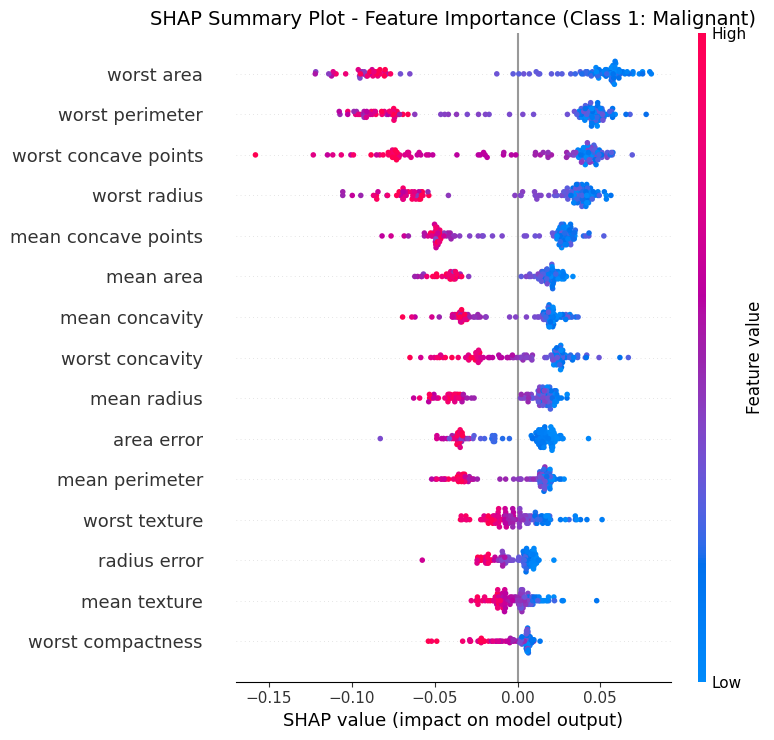

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]  # (n_samples, n_features)
else:
    shap_values_class1 = shap_values

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_test, show=False, max_display=15)

plt.title('SHAP Summary Plot - Feature Importance (Class 1: Malignant)', fontsize=14)
plt.tight_layout()
plt.show()

SHAP показывает вклад каждого признака в конкретное предсказание, учитывает направление влияния, может выявить более тонкие паттерны. 

Число ошибок: 5
Индекс ошибочного объекта: 3
Истинный класс: 1
Предсказанный класс: 0


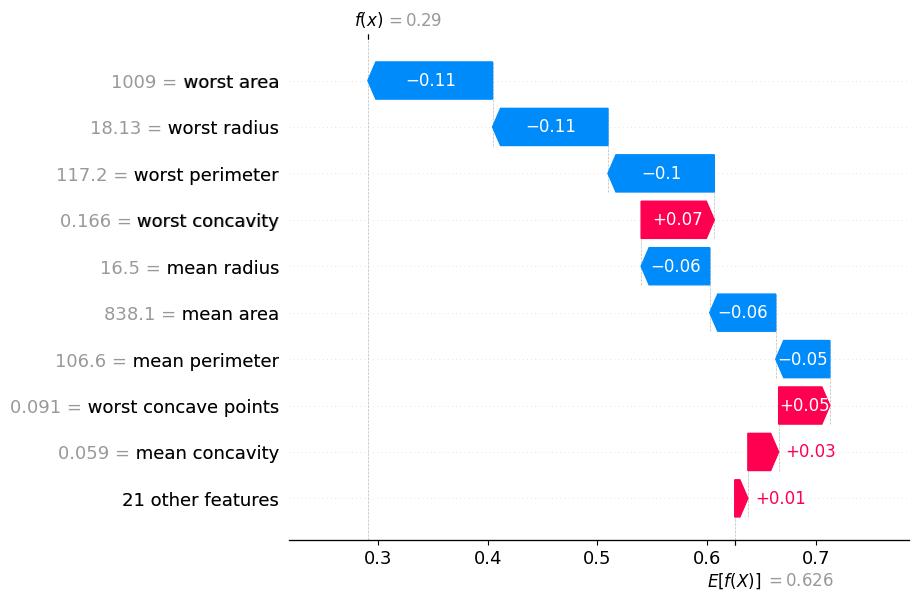

<Figure size 640x480 with 0 Axes>

In [33]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
#║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")

if len(errors) > 0:
    error_idx = errors[0]
    print(f"Индекс ошибочного объекта: {error_idx}")
    print(f"Истинный класс: {y_test.iloc[error_idx]}")
    print(f"Предсказанный класс: {y_pred_test[error_idx]}")
    
    # Получаем SHAP значения для этого объекта (для класса 1)
    if len(shap_values.shape) == 3:
        shap_values_error = shap_values[error_idx, :, 1]
    else:
        shap_values_error = shap_values[error_idx]
    
    # Получаем expected value
    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    elif isinstance(explainer.expected_value, np.ndarray):
        expected_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        expected_value = explainer.expected_value
    
    # Преобразуем в обычные числа
    shap_values_error = np.array(shap_values_error).flatten()
    if hasattr(expected_value, 'flatten'):
        expected_value = expected_value.flatten()[0]
    else:
        expected_value = float(expected_value) if np.isscalar(expected_value) else expected_value[0]
    
    # Получаем имена признаков
    if hasattr(X_test, 'columns'):
        feature_names = X_test.columns
    else:
        feature_names = [f"Feature_{i}" for i in range(len(shap_values_error))]
    
    # Используем waterfall_plot
    plt.figure(figsize=(12, 6))
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_error,
            base_values=expected_value,
            data=X_test.iloc[error_idx].values.flatten(),
            feature_names=feature_names
        ),
        max_display=10,
        show=True
    )
    plt.tight_layout()
    plt.show()
    

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [34]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

rf_with_leak = RandomForestClassifier(random_state=42)
rf_with_leak.fit(X_train_ext, y_train)

y_pred_clean = best_rf.predict(X_test)
y_pred_leak = rf_with_leak.predict(X_test_ext)

print()
print(f"Модель без утечки (на X_test): F1 = {f1_score(y_test, y_pred_clean, average='macro'):.4f}")
print(f"Модель с утечкой (на X_test_ext): F1 = {f1_score(y_test, y_pred_leak, average='macro'):.4f}")

importance_leak = pd.DataFrame({
    'feature': X_train_ext.columns,
    'importance': rf_with_leak.feature_importances_
}).sort_values('importance', ascending=False)


print("\nтоп-10 важных признаков (модель с утечкой)")
print(importance_leak.head(10).to_string(index=False))

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Оценка качества модели с подозрительными признаками
F1-macro на тесте: 1.0000
Accuracy на тесте: 1.0000

Permutation Importance для подозрительных признаков

Топ-10 признаков по Permutation Importance:
               feature  importance_mean  importance_std
         leaky_feature         0.263342        0.043714
   mean concave points         0.004689        0.004689
  worst concave points         0.003752        0.004595
           mean radius         0.000000        0.000000
             mean area         0.000000        0.000000
       mean smoothness         0.000000        0.000000
        mean perimeter         0.000000        0.000000
          mean texture         0.000000        0.000000
         mean symmetry         0.000000        0.000000
mean fractal dimension         0.000000        0.000000

SHAP ANALYSIS для подозрительных признаков


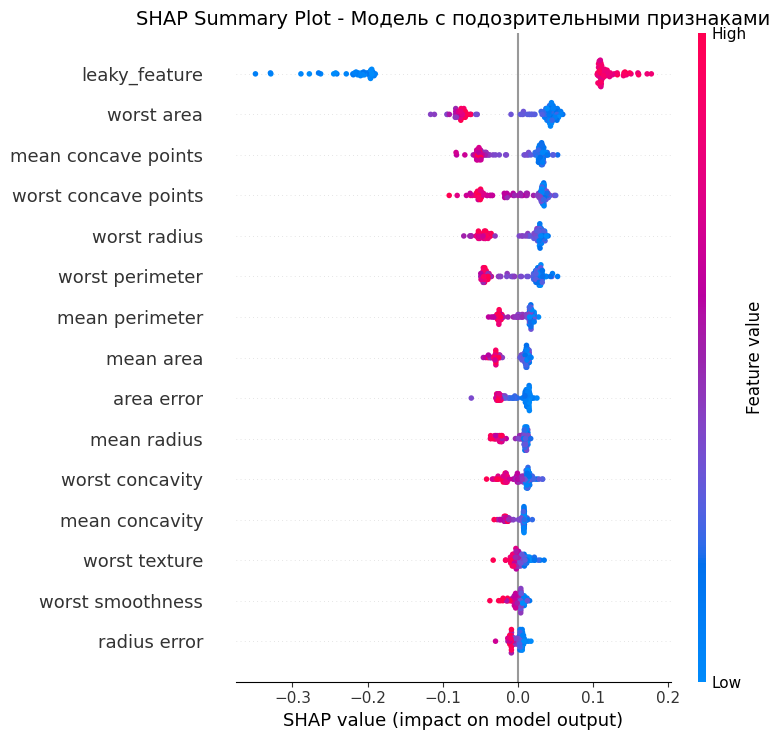

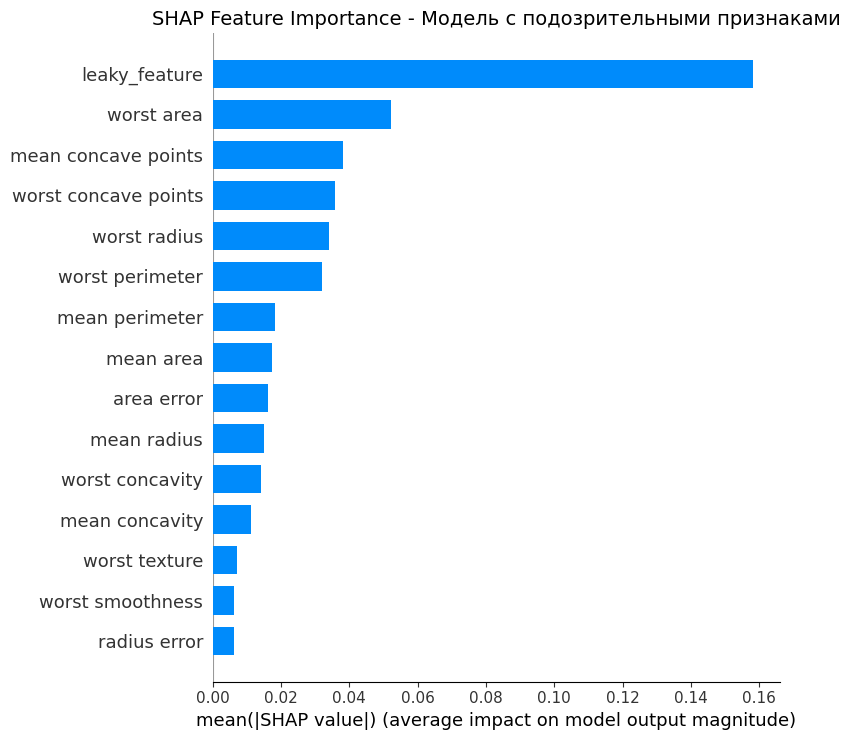


Топ-10 признаков по SHAP (mean |SHAP|):
             feature  mean_abs_shap
       leaky_feature       0.158200
          worst area       0.052164
 mean concave points       0.038178
worst concave points       0.035742
        worst radius       0.033965
     worst perimeter       0.031972
      mean perimeter       0.018102
           mean area       0.017235
          area error       0.016294
         mean radius       0.014903


In [36]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝
from sklearn.metrics import accuracy_score
# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_ext.fit(X_train_ext, y_train)

# Оценка качества
y_pred_ext = rf_ext.predict(X_test_ext)
print("="*70)
print("Оценка качества модели с подозрительными признаками")
print("="*70)
print(f"F1-macro на тесте: {f1_score(y_test, y_pred_ext, average='macro'):.4f}")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_ext):.4f}")

# Permutation Importance
print("\n" + "="*70)
print("Permutation Importance для подозрительных признаков")
print("="*70)

pi_ext = permutation_importance(
    rf_ext, 
    X_test_ext, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro',
    n_jobs=-1
)

# Создаем DataFrame для PI
pi_ext_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance_mean': pi_ext.importances_mean,
    'importance_std': pi_ext.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nТоп-10 признаков по Permutation Importance:")
print(pi_ext_df.head(10).to_string(index=False))

# SHAP значения для новой модели
print("\n" + "="*70)
print("SHAP ANALYSIS для подозрительных признаков")
print("="*70)

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

if len(shap_values_ext.shape) == 3:
    shap_values_ext_class1 = shap_values_ext[:, :, 1]
else:
    shap_values_ext_class1 = shap_values_ext

# SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_ext_class1, X_test_ext, show=False, max_display=15)
plt.title('SHAP Summary Plot - Модель с подозрительными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# SHAP bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_ext_class1, X_test_ext, plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance - Модель с подозрительными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# Анализ важности по SHAP
mean_shap_ext = np.abs(shap_values_ext_class1).mean(axis=0)
shap_ext_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'mean_abs_shap': mean_shap_ext
}).sort_values('mean_abs_shap', ascending=False)

print("\nТоп-10 признаков по SHAP (mean |SHAP|):")
print(shap_ext_df.head(10).to_string(index=False))

a) Как PI определяет leaky_feature? leaky_feature имеет огромное значение PI = 0.263 (это аномально высоко), стандартное отклонение 0.044
Почему метрика на тесте выросла? leaky_feature содержит прямую информацию о целевом классе, модель просто "читает" ответ из этого признак, 
даже с шумом, корреляция ≈ 0.99
б) Как SHAP выделяет leaky_feature в summary plot?  shap покажет огромный разброс значений, четкую линейную зависимость, максимальное среднее
в) Как обнаружить random_feature как «шумовой»? Pi ≈ 0, shap значения ≈ 0 для всех объектов, корреляция с таргетом близка к 0, распределение близко к нормальному N(0,1)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [37]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
summary_table = pd.DataFrame({
    'Метод': ['SVM baseline', 'SVM Grid Search', 'RF baseline', 'RF Random Search'],
    'CV F1 (mean)': [
        baseline_results['SVM'][0],
        svm_grid_search.best_score_,
        baseline_results['RandomForest'][0],
        rf_random_search.best_score_
    ],
    'CV F1 (std)': [
        baseline_results['SVM'][1],
        svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_],
        baseline_results['RandomForest'][1],
        rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]
    ],
    'Test F1': [
        f1_score(y_test, base_models['SVM'].fit(X_train, y_train).predict(X_test), average='macro'),
        f1_score(y_test, svm_grid_search.best_estimator_.predict(X_test), average='macro'),
        f1_score(y_test, base_models['RandomForest'].fit(X_train, y_train).predict(X_test), average='macro'),
        f1_score(y_test, rf_random_search.best_estimator_.predict(X_test), average='macro')
    ],
    'Выводы': [
        'Отличная baseline модель',
        'Незначительное улучшение',
        'Хорошая baseline модель',
        'Стабильная, но медленнее SVM'
    ]
})
print(summary_table.to_string(index=False, float_format='%.4f'))


           Метод  CV F1 (mean)  CV F1 (std)  Test F1                       Выводы
    SVM baseline        0.9694       0.0193   0.9812     Отличная baseline модель
 SVM Grid Search        0.9786       0.0176   0.9812     Незначительное улучшение
     RF baseline        0.9504       0.0255   0.9526      Хорошая baseline модель
RF Random Search        0.9554       0.0204   0.9526 Стабильная, но медленнее SVM


1. незначительно (практически отсутствует) в SVM, в RF минимальное улучшение. Тюнинг гиперпараметров в данном случае НЕ ДАЛ ЗНАЧИМОГО УЛУЧШЕНИЯ, так как baseline модели уже работали на пределе своего качества для этого датасета.
2. Нет, совпадают 2 из 5 признаков. Почему? разная методология, учет направления влияния, корреляция признаков
3. при кросс валидации могла бы быть утечка данных, нарущения вопроизведения, ошибки масштабирования
4. Во-первых, для разведки и отбора данных, далее, бизнес-интерперетация, в-третьих, обнаружение проблем, и наконец, улучшение модели

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")